# This is the Make_sum_more model using Multi-layer perceptron.

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
#Read all of the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
#Build the vocab of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
#Build the dataset

block_size = 3 #context length, how many characters should we take to predict the next one
X, y = [], []
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.': #for padding
        ix = stoi[ch]
        X.append(context)
        y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] #crop and append

X = torch.tensor(X)
y = torch.tensor(y)

In [6]:
X.shape, X.dtype, y.shape, y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [7]:
C = torch.randn((27, 2)) #(rows, columns)

In [8]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [9]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [10]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [ ]:
h

tensor([[ 0.9557, -0.8151, -0.6960,  ...,  0.6302,  0.9995,  0.9993],
        [ 0.9975, -0.9021, -0.7348,  ...,  0.5242,  0.9995,  0.9982],
        [-0.0217, -0.9252, -0.1258,  ...,  0.8471,  1.0000,  0.9492],
        ...,
        [ 0.0783, -0.3906,  0.7863,  ...,  0.2688, -0.1843,  0.9958],
        [ 0.9760, -0.6933, -0.8373,  ..., -0.5746, -0.7935,  0.9996],
        [ 0.9454, -0.4513,  0.9784,  ...,  0.9902, -0.9968, -0.6726]])

In [12]:
h.shape

torch.Size([228146, 100])

In [13]:
W2 = torch.randn(100, 27)
b2 = torch.randn(27)

In [14]:
logits = h @ W2 + b2

In [43]:
counts = logits.exp()

In [44]:
prob = counts / counts.sum(1, keepdims=True)

In [45]:
prob[0].sum() #adds to one, so it normalized

tensor(1., grad_fn=<SumBackward0>)

In [46]:
y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [53]:
loss = -prob[torch.arange(32), y[ix]].log().mean()
loss

tensor(3.5006, grad_fn=<NegBackward0>)

In [68]:
F.cross_entropy(logits, y[ix])
parameters = [C, W1, b1, W2, b2]

In [69]:
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((27, 2))
W1 = torch.randn((6, 100))
b1 = torch.randn(100)
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [70]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [79]:
#training loop
lri = []
lossi = []

epochs = 10000
for i in range(epochs):
    #mini-batch constuct
    ix = torch.randint(0, X.shape[0], (32,))

    #forward pass
    emb = C[X[ix]] #[32, 3, 2]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #[32, 100]
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y[ix])
    # print(loss.item())
    #Backpropogation
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad #lr is the learning rate

    #track stats
    # lri.append(lr)
    # lossi.append(loss.item())
# print(loss.item())



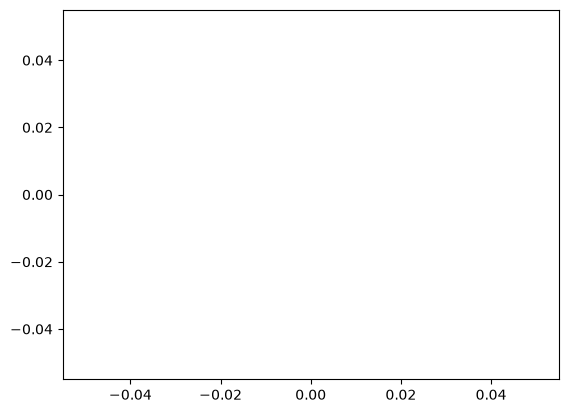

In [72]:
plt.plot(lri, lossi)

In [80]:
emb = C[X[ix]] #[32, 3, 2]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #[32, 100]
logits = h @ W2 + b2
loss = F.cross_entropy(logits, y[ix])   
loss

tensor(1.8706, grad_fn=<NllLossBackward0>)

In [ ]:
#Training split, validation split and test split
#80%, 10%, 10%           